```markdown
# 05 - Dimensional Data Modeling

## Objective

This notebook transforms the curated Airbnb master dataset into a dimensional model designed for analytical querying.

The model follows a star-schema approach, separating descriptive business entities into dimension tables and numerical analytical measures into a fact table.

## Analytical Goal

The dimensional model supports efficient analysis of listing price, availability, review activity, and neighbourhood-level market patterns across London and New York.

## Output Tables

- `dim_city`
- `dim_neighbourhood`
- `dim_listing`
- `fact_listing`

## Data Model Grain

The central fact table is maintained at **one row per Airbnb listing snapshot**.

This is a listing-level analytical model, not a booking or reservation transaction model.
```


## 1. Load Curated Master Dataset

The curated master dataset created during data enrichment is loaded as the source for dimensional modeling.

This dataset already contains cleaned listing attributes, review summaries, calendar availability metrics, derived features, and neighbourhood-level context.

The dimensional model restructures this enriched dataset into tables that are easier to query using SQL and analytical tools.

In [15]:
import pandas as pd

master_dataset = pd.read_csv(
    "../data/curated/master_airbnb_dataset.csv",
    low_memory=False
)

print(master_dataset.shape)

ParserError: Error tokenizing data. C error: out of memory

In [ ]:
# Validate whether a listing ID appears in more than one city
cross_city_id_collisions = (
    master_dataset.groupby("id")["city"]
    .nunique()
    .gt(1)
    .sum()
)

print("Listing IDs appearing in more than one city:", cross_city_id_collisions)

Listing IDs appearing in more than one city: 0


## 2. City Dimension

The city dimension stores one record for each analysed market.

A surrogate key named `city_id` is created to provide a compact and consistent identifier for use in the fact table and related dimensions.

This design supports cross-city analysis while avoiding repeated use of city names in analytical joins.

In [ ]:
dim_city = (
    master_dataset[["city"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

dim_city["city_id"] = (
    dim_city.index + 1
)

dim_city

,city,city_id
0,London,1
1,New York,2


## 3. Neighbourhood Dimension

The neighbourhood dimension stores unique city and neighbourhood combinations.

Neighbourhood names are city-specific. Therefore, the dimension includes both `city_id` and `neighbourhood_cleansed` so that locations are interpreted within the correct market.

Each unique neighbourhood receives a surrogate key named `neighbourhood_id`.

In [ ]:
dim_neighbourhood = (
    master_dataset[
        ["city", "neighbourhood_cleansed"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

dim_neighbourhood["neighbourhood_id"] = (
    dim_neighbourhood.index + 1
)

print(dim_neighbourhood.shape)

dim_neighbourhood.head()

(257, 3)


,city,neighbourhood_cleansed,neighbourhood_id
0,London,Islington,1
1,London,Kensington and Chelsea,2
2,London,Westminster,3
3,London,Wandsworth,4
4,London,Tower Hamlets,5


In [ ]:
dim_neighbourhood = dim_neighbourhood.merge(
    dim_city,
    on="city",
    how="left"
)

dim_neighbourhood = dim_neighbourhood[
    ["neighbourhood_id", "city_id", "city", "neighbourhood_cleansed"]
]

dim_neighbourhood.head()

,neighbourhood_id,city_id,city,neighbourhood_cleansed
0,1,1,London,Islington
1,2,1,London,Kensington and Chelsea
2,3,1,London,Westminster
3,4,1,London,Wandsworth
4,5,1,London,Tower Hamlets


## 4. Listing Dimension

The listing dimension stores descriptive attributes associated with each Airbnb listing.

The table includes:

- `listing_id`
- `room_type`
- `property_type`

Separating descriptive attributes from numerical measures keeps the fact table focused on analytical metrics and allows more listing attributes to be added later without redesigning the fact table.

In [ ]:
dim_listing = (
    master_dataset[
        [
            "id",
            "room_type",
            "property_type"
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

dim_listing = dim_listing.rename(
    columns={
        "id": "listing_id"
    }
)

print(dim_listing.shape)

dim_listing.head()

(131907, 3)


,listing_id,room_type,property_type
0,13913,Private room,Private room in rental unit
1,15400,Entire home/apt,Entire rental unit
2,17402,Entire home/apt,Entire rental unit
3,24328,Entire home/apt,Entire townhouse
4,36274,Entire home/apt,Entire condo


## 5. Listing Fact Table

The fact table contains the numerical measures used for reporting and market analysis.

Each row represents one listing snapshot and links to the relevant city and neighbourhood dimensions.

Key measures include:

- `price_clean`
- `availability_rate`
- `occupancy_rate`
- `total_reviews`
- `review_frequency`
- `price_per_bedroom`
- `host_tenure_years`

`occupancy_rate` is treated as an occupancy/unavailability proxy because calendar dates marked unavailable may represent confirmed bookings, host-blocked dates, or other listing restrictions.

In [ ]:
fact_listing = master_dataset.merge(
    dim_city,
    on="city",
    how="left"
)

In [ ]:
fact_listing = fact_listing.merge(
    dim_neighbourhood[
        [
            "city_id",
            "neighbourhood_cleansed",
            "neighbourhood_id"
        ]
    ],
    on=[
        "city_id",
        "neighbourhood_cleansed"
    ],
    how="left"
)

In [ ]:
fact_listing = fact_listing[
    [
        "id",
        "city_id",
        "neighbourhood_id",

        "price_clean",
        "availability_rate",
        "occupancy_rate",

        "total_reviews",
        "review_frequency",

        "price_per_bedroom",

        "host_tenure_years"
    ]
]

In [ ]:
fact_listing = fact_listing.rename(
    columns={
        "id": "listing_id"
    }
)

print(fact_listing.shape)

fact_listing.head()

(131907, 10)


,listing_id,city_id,neighbourhood_id,price_clean,availability_rate,occupancy_rate,total_reviews,review_frequency,price_per_bedroom,host_tenure_years
0,13913,1,1,70.0,0.906849,0.093151,55.0,3.471382,70.0,15.843836
1,15400,1,2,149.0,0.545205,0.454795,97.0,6.142436,149.0,15.791781
2,17402,1,3,411.0,0.219178,0.780822,56.0,3.564702,137.0,15.709589
3,24328,1,4,NaN,0.805479,0.194521,95.0,5.943606,NaN,15.983562
4,36274,1,5,210.0,0.884932,0.115068,15.0,0.979428,NaN,15.315068


### Fact Table Design Rationale

The listing-level fact-table grain was selected because the available data represents a marketplace snapshot rather than a complete booking transaction history.

A booking-level fact table was not created because confirmed reservation, revenue, and guest-stay transaction data were not available in the supplied source extracts.

This model is therefore optimized for listing-performance analytics rather than financial booking reconciliation.

## Star Schema Diagram

The diagram below shows the analytical relationships between the listing fact table and its supporting dimensions.

`fact_listing` is the central analytical table. It links to the city, neighbourhood, and listing dimensions through surrogate and business keys.

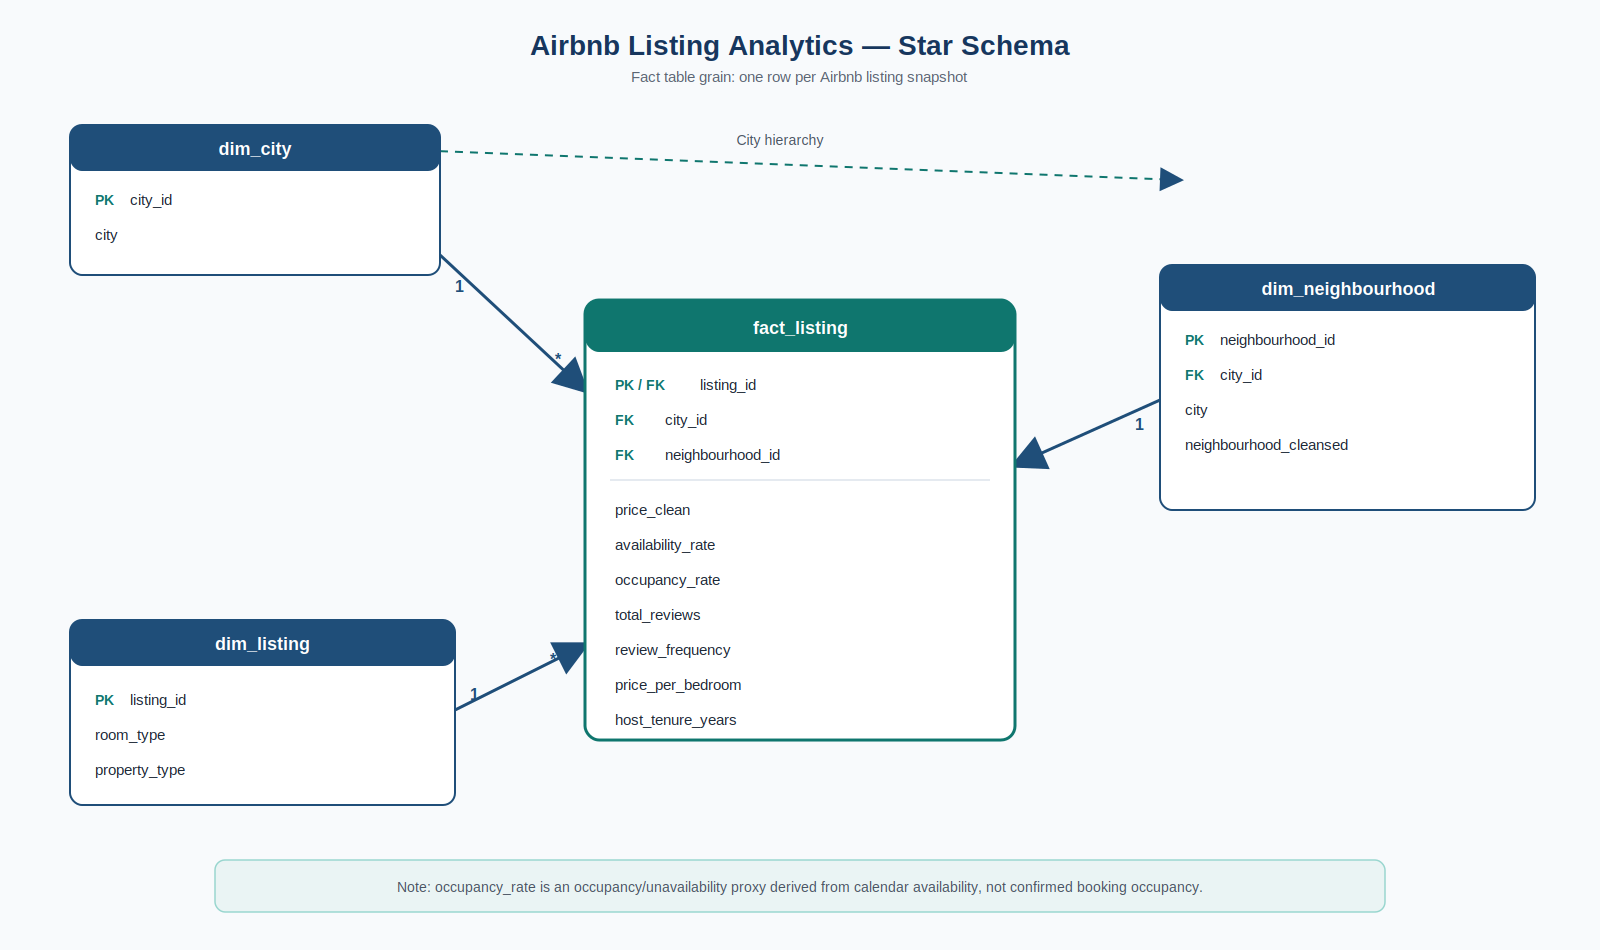

Star schema diagram displayed and saved to docs/star_schema.svg


In [17]:
from pathlib import Path
from IPython.display import SVG, display

svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="1600" height="950" viewBox="0 0 1600 950">

  <defs>
    <marker id="arrow" markerWidth="12" markerHeight="12" refX="10" refY="6" orient="auto">
      <path d="M0,0 L12,6 L0,12 Z" fill="#1F4E79"/>
    </marker>

    <style>
      .title { font-family: Arial, sans-serif; font-size: 28px; font-weight: bold; fill: #17365D; }
      .subtitle { font-family: Arial, sans-serif; font-size: 15px; fill: #5B6573; }
      .table-title { font-family: Arial, sans-serif; font-size: 18px; font-weight: bold; fill: white; }
      .field { font-family: Arial, sans-serif; font-size: 15px; fill: #1F2937; }
      .key { font-family: Arial, sans-serif; font-size: 14px; font-weight: bold; fill: #0F766E; }
      .relation { font-family: Arial, sans-serif; font-size: 16px; font-weight: bold; fill: #1F4E79; }
      .note { font-family: Arial, sans-serif; font-size: 14px; fill: #4B5563; }
    </style>
  </defs>

  <rect width="1600" height="950" fill="#F8FAFC"/>

  <text x="800" y="55" text-anchor="middle" class="title">
    Airbnb Listing Analytics — Star Schema
  </text>

  <text x="800" y="82" text-anchor="middle" class="subtitle">
    Fact table grain: one row per Airbnb listing snapshot
  </text>

  <!-- Relationships -->
  <line x1="440" y1="255" x2="585" y2="390"
        stroke="#1F4E79" stroke-width="3" marker-end="url(#arrow)"/>

  <line x1="1160" y1="400" x2="1015" y2="465"
        stroke="#1F4E79" stroke-width="3" marker-end="url(#arrow)"/>

  <line x1="455" y1="710" x2="585" y2="645"
        stroke="#1F4E79" stroke-width="3" marker-end="url(#arrow)"/>

  <!-- City to Neighbourhood hierarchy -->
  <line x1="410" y1="150" x2="1180" y2="180"
        stroke="#0F766E" stroke-width="2" stroke-dasharray="8,7" marker-end="url(#arrow)"/>

  <!-- Relationship labels -->
  <text x="455" y="292" class="relation">1</text>
  <text x="555" y="365" class="relation">*</text>

  <text x="1135" y="430" class="relation">1</text>
  <text x="1030" y="455" class="relation">*</text>

  <text x="470" y="700" class="relation">1</text>
  <text x="550" y="665" class="relation">*</text>

  <text x="780" y="145" text-anchor="middle" class="note">
    City hierarchy
  </text>

  <!-- dim_city -->
  <rect x="70" y="125" width="370" height="150" rx="12" fill="white" stroke="#1F4E79" stroke-width="2"/>
  <rect x="70" y="125" width="370" height="46" rx="12" fill="#1F4E79"/>
  <text x="255" y="155" text-anchor="middle" class="table-title">dim_city</text>

  <text x="95" y="205" class="key">PK</text>
  <text x="130" y="205" class="field">city_id</text>

  <text x="95" y="240" class="field">city</text>

  <!-- dim_neighbourhood -->
  <rect x="1160" y="265" width="375" height="245" rx="12" fill="white" stroke="#1F4E79" stroke-width="2"/>
  <rect x="1160" y="265" width="375" height="46" rx="12" fill="#1F4E79"/>
  <text x="1348" y="295" text-anchor="middle" class="table-title">dim_neighbourhood</text>

  <text x="1185" y="345" class="key">PK</text>
  <text x="1220" y="345" class="field">neighbourhood_id</text>

  <text x="1185" y="380" class="key">FK</text>
  <text x="1220" y="380" class="field">city_id</text>

  <text x="1185" y="415" class="field">city</text>
  <text x="1185" y="450" class="field">neighbourhood_cleansed</text>

  <!-- dim_listing -->
  <rect x="70" y="620" width="385" height="185" rx="12" fill="white" stroke="#1F4E79" stroke-width="2"/>
  <rect x="70" y="620" width="385" height="46" rx="12" fill="#1F4E79"/>
  <text x="262" y="650" text-anchor="middle" class="table-title">dim_listing</text>

  <text x="95" y="705" class="key">PK</text>
  <text x="130" y="705" class="field">listing_id</text>

  <text x="95" y="740" class="field">room_type</text>
  <text x="95" y="775" class="field">property_type</text>

  <!-- fact_listing -->
  <rect x="585" y="300" width="430" height="440" rx="14" fill="white" stroke="#0F766E" stroke-width="3"/>
  <rect x="585" y="300" width="430" height="52" rx="14" fill="#0F766E"/>
  <text x="800" y="334" text-anchor="middle" class="table-title">fact_listing</text>

  <text x="615" y="390" class="key">PK / FK</text>
  <text x="700" y="390" class="field">listing_id</text>

  <text x="615" y="425" class="key">FK</text>
  <text x="665" y="425" class="field">city_id</text>

  <text x="615" y="460" class="key">FK</text>
  <text x="665" y="460" class="field">neighbourhood_id</text>

  <line x1="610" y1="480" x2="990" y2="480" stroke="#CBD5E1" stroke-width="1"/>

  <text x="615" y="515" class="field">price_clean</text>
  <text x="615" y="550" class="field">availability_rate</text>
  <text x="615" y="585" class="field">occupancy_rate</text>
  <text x="615" y="620" class="field">total_reviews</text>
  <text x="615" y="655" class="field">review_frequency</text>
  <text x="615" y="690" class="field">price_per_bedroom</text>
  <text x="615" y="725" class="field">host_tenure_years</text>

  <!-- Footer note -->
  <rect x="215" y="860" width="1170" height="52" rx="10" fill="#EAF4F4" stroke="#99D6CF" stroke-width="1.5"/>
  <text x="800" y="892" text-anchor="middle" class="note">
    Note: occupancy_rate is an occupancy/unavailability proxy derived from calendar availability, not confirmed booking occupancy.
  </text>

</svg>
"""

display(SVG(svg))

output_dir = Path("../docs")
output_dir.mkdir(exist_ok=True)

with open(output_dir / "star_schema.svg", "w", encoding="utf-8") as file:
    file.write(svg)

print("Star schema diagram displayed and saved to docs/star_schema.svg")

### Schema Interpretation

The `fact_listing` table stores measures at one row per listing snapshot.

- `dim_city` provides city-level context.
- `dim_neighbourhood` provides location context within each city.
- `dim_listing` provides property and room-type attributes.

This structure supports efficient SQL analysis of price, availability, reviews, room type, and neighbourhood-level market patterns.

## 6. Curated Analytical Layer

The dimensional tables are saved to the curated data layer.

This separates analytics-ready outputs from earlier data layers:

- **Raw layer:** Original Inside Airbnb source files
- **Processed layer:** Cleaned and enriched intermediate datasets
- **Curated layer:** Dimensional tables designed for SQL analytics and dashboard use

In [ ]:
dim_city.to_csv("../data/curated/dim_city.csv", index=False)
dim_neighbourhood.to_csv("../data/curated/dim_neighbourhood.csv", index=False)
dim_listing.to_csv("../data/curated/dim_listing.csv", index=False)
fact_listing.to_csv("../data/curated/fact_listing.csv", index=False)

print("Star schema tables saved successfully.")

Star schema tables saved successfully.


## Data Modeling Summary and Next Steps

A star-schema-inspired dimensional model was created for Airbnb listing analytics.

Key outcomes:

1. A city dimension was created to support multi-city analysis.
2. A neighbourhood dimension was created using unique city and neighbourhood combinations.
3. A listing dimension was created for descriptive listing attributes.
4. A listing-level fact table was created to store price, availability, review, and derived analytical measures.
5. The model preserves one row per listing snapshot.
6. Curated dimension and fact tables were saved for SQL querying and dashboard consumption.

The next notebook uses DuckDB to query the dimensional model and generate business-oriented analytical insights.